In [1]:
""" example code for fitting SEDs """
# pylint: disable=invalid-name, no-member, missing-function-docstring, line-too-long
import warnings
from pathlib import Path
import json
import re

import numpy as np

import corner

# Support for interactive widgets
from IPython.display import display
from ipywidgets import Dropdown

# %matplotlib widget
import matplotlib.pyplot as plt

# pylint: disable=wrong-import-position
warnings.filterwarnings("ignore", "Using UFloat objects with std_dev==0 may give unexpected results.", category=UserWarning)
from uncertainties import ufloat, nominal_value as nom_val
from uncertainties.unumpy import nominal_values as nom_vals
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia

from dust_extinction.parameter_averages import F99, F04, G23

from deblib.constants import M_sun, R_sun
from deblib.stellar import log_g

from support.extinction import get_gontcharov_av
from support.pipeline import get_teff_from_spt
from support.sed import get_sed_for_target, retain_only_best_observations
from support.plots import plot_sed, plot_fitted_model

from sed_fit.fitter import create_theta, model_func, minimize_fit, mcmc_fit
from sed_fit.generic_fitter import samples_from_sampler
from sed_fit.stellar_grids import StellarGrid

### Set up the extinction model

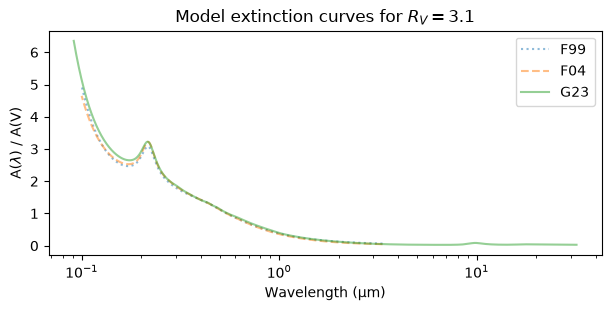

Using the G23 extinction model covers the range from 0.0912 µm to 32.0 µm.


In [2]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), constrained_layout=True)
for (_mod, _ls) in [(F99, ":"), (F04, "--"), (G23, "-")]:
    _lambda = (1 / np.logspace(*np.log10(_mod.x_range), num=1000)) * u.um
    ax.plot(_lambda, _mod(Rv=3.1)(_lambda), ls=_ls, alpha=0.5, label=f"{_mod.name}")
ax.set(title="Model extinction curves for $R_V=3.1$", xscale="log",
       xlabel=f"Wavelength ({_lambda.unit:latex_inline})", ylabel=r"A($\lambda$) / A(V)")
ax.legend(loc="best")
plt.show(fig)
plt.close(fig)

# The G23 (Gordon et al., 2023) Milky Way R(V) filter gives us the broadest coverage
ext_model = G23(Rv=3.1)
ext_wl_range = np.reciprocal(ext_model.x_range) * u.um # x_range has implicit units of 1/micron
print(f"Using the {ext_model.__class__.__name__} extinction model covers the range from",
      f"{min(ext_wl_range):unicode} to {max(ext_wl_range):unicode}.")

### Load the model grid used for generating synthetic SEDs 
These create a flux interpolator over grid of fluxes across a range of $T_{\rm eff}$, $\log{g}$
and metallicities. The grids support the option of "quick mode" which creates a further set of
interpolators for pre-filtered and summed fluxes for each supported filter, over the same ranges.
When using quick mode, any extinction calculations are simplified by being made after the filter
and treating all of the flux as a single value with the filter's mean wavelength.

In [3]:
use_quick_mode = True

# Both BtSettlGrid & KuruczGrid available with the former having better coverage but slower/larger
# Alternatively there is a simple BlackBodyGrid.
model_grid = StellarGrid.get_instance("BtSettlGrid", extinction_model=ext_model, verbose=True,
                                      use_quick_mode=use_quick_mode, interp_method="linear")

print(f"Loaded {model_grid.__class__.__name__} covering the ranges:")
print(f"wavelength {model_grid.wavelength_range * model_grid.wavelength_unit:unicode},",
      f"Teff {model_grid.teff_range * model_grid.teff_unit:unicode},",
      f"logg {model_grid.logg_range * model_grid.logg_unit:unicode}",
      f"\nand metallicity {model_grid.metal_range * u.dimensionless_unscaled:unicode},",
      f"with fluxes returned in units of {model_grid.flux_unit:unicode}")

Loading model grid from bt-settl-agss.npz created at 2026-07-25 17:56:37.104721+00:00
BtSettlGrid is initializing the fluxes interpolator with a grid of 112 teff, 6 logg & 4 metal values and 5000 wavelength bins...will use linear interpolation...done.
The use of quick mode requested so will set up pre-filtered fluxes.
Initializing pre-filtered fluxes for 38 filters......................................done.
Loaded BtSettlGrid covering the ranges:
wavelength [ 0.09120575 31.99861909] µm, Teff [ 2000. 40000.] K, logg [3.  5.5] dex 
and metallicity [-0.5  0.5], with fluxes returned in units of W m⁻²


### Select our target and get its known information

In [4]:
default_target = "V530 Ori"
fit_av = True
targets_config_file = Path.cwd() / "config" / "fitting-a-sed-targets.json"
with open(targets_config_file, mode="r", encoding="utf8") as f:
    full_dict = json.load(f)
targets_cfg = { k: full_dict[k] for k in full_dict if full_dict[k].get("enabled", True) }

max_teff = max(model_grid.teff_range * model_grid.teff_unit).to(u.K).value
options = [
    (f"{t}" + (" *" if c.get("exclude", False) else "") + (" [too hot!]" if min(c["TeffA"], c["TeffB"]) > max_teff else ""), t)
        for t, c in targets_cfg.items()
]

target_selection = Dropdown(options=options, value=default_target, description="Targets:")
display(target_selection)

Dropdown(description='Targets:', index=28, options=(('V436 Per', 'V436 Per'), ('V539 Ara', 'V539 Ara'), ('MU C…

In [5]:
target = target_selection.value
target_config = targets_cfg[target]
target_config.setdefault("loggA", log_g(target_config["MA"] * M_sun, target_config["RA"] * R_sun).n)
target_config.setdefault("loggB", log_g(target_config["MB"] * M_sun, target_config["RB"] * R_sun).n)

# Additional data on the target populated with lookups
target_data = {
    "label": target_config.get("label", target),
    "search_term": target_config.get("search_term", target)
}

_simbad = Simbad()
_simbad.add_votable_fields("sp", "ids")
if _tbl := _simbad.query_object(target_data["search_term"]):
    target_data["ids"] = np.array(re.findall(r"(Gaia DR3|V\*|TIC|HD|HIP|2MASS)\s+(.+?(?=\||$))", _tbl["ids"][0]),
                                    dtype=[("type", object), ("id", object)])
    print("IDs:", ", ".join(f"{i['type']} {i['id']}" for i in target_data["ids"]))
    target_data["spt"] = _tbl["sp_type"][0]
    print("SpT:", target_data["spt"])

IDs: TIC 11961096, V* V530 Ori, Gaia DR3 3024802671798151296, 2MASS J06043380-0311513, HD 294598
SpT: G0


In [6]:
# Let's get the Gaia DR3 data on this here object
_gaia_dr3_id = target_data["ids"][target_data["ids"]["type"] == "Gaia DR3"]["id"][0]
if _job := Gaia.launch_job(f"SELECT TOP 1 * FROM gaiadr3.gaia_source_lite WHERE source_id = {_gaia_dr3_id}"):
    _tbl = _job.get_results()
    target_data["ruwe"] = _tbl["ruwe"][0]
    target_data["distance"] = 1000 / ufloat(_tbl["parallax"][0], _tbl["parallax_error"][0])
    target_data["skycoords"] = _coords = SkyCoord(ra=_tbl["ra"][0] * u.deg, dec=_tbl["dec"][0] * u.deg,
                                                  distance=1000 / _tbl["parallax"][0] * u.pc, frame="icrs")
    print(f"{target} SkyCoords are {_coords} (or {_coords.to_string('hmsdms')})")
    print(f"ruwe = {target_data.get('ruwe', 0):.3f}")

V530 Ori SkyCoords are <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    (91.14104007, -3.19808924, 102.42838593)> (or 06h04m33.84961699s -03d11m53.12126603s)
ruwe = 1.244


In [7]:
# Lookup the TESS Input Catalog (8.2) for starting "system" Teff and logg values
target_data["teff_sys"] = get_teff_from_spt(target_data["spt"]) or ufloat(5700, 0)
target_data["logg_sys"] = ufloat(4.0, 0)
if _tbl := Vizier(catalog="IV/39/tic82").query_object(target_data["search_term"], radius=0.1 * u.arcsec):
    if _row := _tbl[0][_tbl[0]["TIC"] in target_data["ids"][target_data["ids"]["type"] == "TIC"]["id"]]:
        # Teff may not be reliable - only use it if it's consistent with the SpT
        if target_data["teff_sys"].n-target_data["teff_sys"].s < (_row["Teff"] or 0) < target_data["teff_sys"].n+target_data["teff_sys"].s:
            target_data["teff_sys"] = ufloat(_row["Teff"], _row.get("s_Teff", None) or 0)
        if (_row["logg"] or 0) > 0:
            target_data["logg_sys"] = ufloat(_row["logg"], _row.get("s_logg", None) or 0)

# Other priors will likely come out of light curve fitting with JKTEBOP - get from config for now
target_data["k"] = ufloat(target_config.get("k"), target_config.get("k_err", 0) or 0)
if "LR" in target_config:
    target_data["light_ratio"] = ufloat(target_config.get("LR"), target_config.get("LR_err", 0) or 0)
elif "light_ratio" in target_config:
    target_data["light_ratio"] = ufloat(target_config.get("light_ratio"), target_config.get("light_ratio_err", 0) or 0)
else:
    # If from LC fit we may also need to consider 3L; l1=(1-3L)/(1+(L2/L1)) & l2=(1-3L)/(1+1/(L2/L1))
    target_data["light_ratio"] = ufloat(10**(target_config.get("logL2", 1) - target_config.get("logL1", 1)), 0)
target_data["teff_ratio"] = (target_data["light_ratio"] / target_data["k"]**2)**0.25

print(f"{target} system values from lookup and LC fitting:")
for p, unit in [("distance", u.pc), ("teff_sys", u.K), ("logg_sys", u.dex), ("k", None), ("light_ratio", None), ("teff_ratio", None)]:
    print(f"{p:>12s} = {target_data[p]:.3f} {unit or u.dimensionless_unscaled:unicode}")

V530 Ori system values from lookup and LC fitting:
    distance = 102.428+/-0.194 pc
    teff_sys = 5742.000+/-136.200 K
    logg_sys = 4.404+/-0.075 dex
           k = 0.600+/-0.004 
 light_ratio = 0.068+/-0.009 
  teff_ratio = 0.659+/-0.022 


### Get the SED data for the target
The initial call the `get_sed_for_target()` will query the
[VizieR Photometry service](https://vizier.cds.unistra.fr/vizier/sed/doc/). This aggregates and returns
photometric observations from across the platform's many catalogues within a chosen radius of the target.
Once received, the table is pre-processed to ensure consistent units, apply default uncertainties where
missing and to remove duplicate rows.

The call to `retain_only_closest_observations()` then removes all but one observation per filter,
with the closes to the target's coordinates being retained.

Finally, the table is further restricted to remove observations with filters not supported by
the stellar model or any that have been explicitly listed for exclusion.

In [8]:
# Read in the SED for this target and de-duplicate (measurements may appear multiple times).
sed = get_sed_for_target(target, target_data["search_term"], radius=0.25, remove_duplicates=True,
                         freq_unit=u.GHz, flux_unit=u.Jy, wl_unit=u.um, verbose=True)
sed = retain_only_best_observations(sed, target_data["skycoords"])

model_mask = np.ones((len(sed)), dtype=bool)
model_mask &= model_grid.has_filter(sed["sed_filter"])
model_mask &= np.isin(sed["sed_filter"], target_config.get("sed_filter_exclusions",[]), invert=True)
model_mask &= np.isin(sed["_tabname"], target_config.get("sed_tabname_exclusions", []), invert=True)
model_mask &= (sed["sed_wl"] >= min(model_grid.wavelength_range)) \
            & (sed["sed_wl"] <= max(model_grid.wavelength_range))
sed = sed[model_mask]

sed.sort(["sed_wl"])
print(f"{len(sed)} unique SED observation(s) retained after range & exclusion filtering,",
      "and the selection of the 'best' observation of the target for each Filter.",
      "\nThe units for flux density, frequency and wavelength are:",
      ", ".join(f"{sed[f].unit:unicode}" for f in ["sed_flux", "sed_freq", "sed_wl"]))
print("Filters (by wavelength):", ", ".join(sed["sed_filter"]))
print("Fluxes (by wavelength):", ", ".join(f"{f:.2e}" for f in sed['sed_flux']))

Opened SED table v530-ori-0.25.vot containing 66 row(s).
Dropped 10 duplicate(s) leaving 56 unique row(s).
13 unique SED observation(s) retained after range & exclusion filtering, and the selection of the 'best' observation of the target for each Filter. 
The units for flux density, frequency and wavelength are: Jy, GHz, µm
Filters (by wavelength): Johnson:B, Johnson:V, 2MASS:J, Johnson:J, Johnson:H, 2MASS:H, 2MASS:Ks, Johnson:K, WISE:W1, Johnson:L, WISE:W2, WISE:W3, WISE:W4
Fluxes (by wavelength): 2.71e-01, 4.06e-01, 5.71e-01, 5.83e-01, 4.93e-01, 4.97e-01, 3.65e-01, 3.47e-01, 1.71e-01, 1.60e-01, 9.27e-02, 1.62e-02, 5.34e-03


### Get the extinction $A_{\rm V}$ value for the target
We have the option of fitting the extinction value $A_{\rm V}$, or we can de-redden the
observations in advance and fix the fitted extinction at zero. The latter approach is quicker as
the extinction calculations are carried out once only rather than on each fitting iteration.

Found an E(B-V) value in config
Will fit extinction based Av=0.139500+/-0.062000


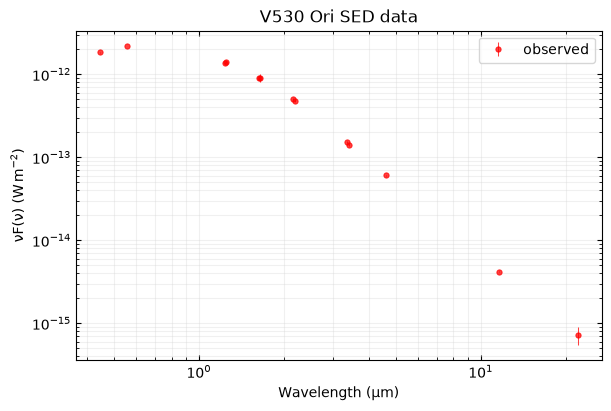

In [9]:
if "av" in target_config:
    Av = ufloat(target_config["av"], target_config.get("av_err", 0))
    print("Found an Av value in config")
elif "ebv" in target_config:
    Av = ufloat(target_config["ebv"], target_config.get("ebv_err", 0)) * 3.1
    print("Found an E(B-V) value in config")
else:
    Av = ufloat(get_gontcharov_av(target_data["skycoords"])[0], 0.04 * 3.1)
    print("Taking Av values from Gontcharov extinction map and target coords")

if fit_av:
    print(f"Will fit extinction based Av={Av:.6f}")
    sed["sed_fit_flux"] = sed["sed_flux"]
    fig = plot_sed(sed["sed_wl"].quantity,
                   fluxes=[sed["sed_fit_flux"].quantity],
                   flux_errs=[sed["sed_eflux"].quantity],
                   fmts=[".r"],
                   labels=["observed"],
                   show_grid=True,
                   title=target_data['label'] + " SED data")
else:
    print(f"Will not fit extinction, so dereddening SED observations with Av={nom_val(Av):.6f}")
    sed["sed_fit_flux"] = sed["sed_flux"] / ext_model.extinguish(sed["sed_wl"].to(u.um), Av=nom_val(Av))
    fig = plot_sed(sed["sed_wl"].quantity,
                   fluxes=[sed["sed_flux"].quantity, sed["sed_fit_flux"].quantity],
                   flux_errs=[sed["sed_eflux"].quantity]*2,
                   fmts=["or", ".b"],
                   labels=["observed", f"dereddened\n($A_{{\\rm V}}={Av:.3f})$"],
                   show_grid=True,
                   title=target_data['label'] + " SED data")
plt.show(fig)
plt.close(fig)

### Set up the functions and data which will support fitting

In [10]:
NUM_STARS = 2

subs = ["ABCDEFGHIJKLM"[n] for n in range(NUM_STARS)]
theta_plot_labels = np.array([f"$T_{{\\rm eff,{sub}}} / {{\\rm K}}$" for sub in subs] \
                            +[f"$\\log{{g}}_{{\\rm {sub}}}$" for sub in subs] \
                            +[f"$R_{{\\rm {sub}}} / {{\\rm R_{{\\odot}}}}$" for sub in subs] \
                            +["${\\rm dist} / {\\rm pc}$", "${\\rm A_{V}}$"])

theta_labels = np.array([(f"Teff{sub}", u.K) for sub in subs] \
                        +[(f"logg{sub}", u.dex) for sub in subs] \
                        +[(f"R{sub}", u.Rsun) for sub in subs] \
                        +[("dist", u.pc), ("av", u.dimensionless_unscaled)])

Here we set up priors' limit and ratio criteria for the fitting. This is in the form of a
callback function which the fitting code invokes at the start of each iteration.

In [11]:
teff_limits = model_grid.teff_range
logg_limits = model_grid.logg_range
radius_limits = (0.1, 100)
av_limits = (-1, 5)

# Ratios wrt the primary component
teff_ratios = [1] + [ufloat(target_data["teff_ratio"].n,
                            max(target_data["teff_ratio"].n*.05, target_data["teff_ratio"].s))] * (NUM_STARS-1)
rad_ratios = [1] + [ufloat(target_data["k"].n,
                           max(target_data["k"].n*.05, target_data["k"].s))] * (NUM_STARS-1)

# Distance & AV priors - only affect the outcome if these are fitted
dist_prior = target_data["distance"]
av_prior = Av

print(f"Priors: TeffR={', '.join(f'{r:.3f}' for r in teff_ratios[1:])},",
        f"radiusR={', '.join(f'{r:.3f}' for r in rad_ratios[1:])},",
        f"dist={dist_prior:.3f},",
        f"av={av_prior:.3f}," if fit_av else "",
        f"Teff_limits={teff_limits}, radius_limits={radius_limits}, av_limits={av_limits}")

def ln_prior_func(theta: np.ndarray[float]) -> float:
    """
    The fitting prior callback function to evaluate the current set of candidate parameters
    (theta), returning a single negative ln(value) indicating their "goodness".

    Return a negative value as emcee will try to maximize the sum of this and the negative value
    of its ln_prob_func. The fitter component knows to flip the sign if we run a minimize fit.
    """
    teffs = theta[0 : NUM_STARS]
    radii = theta[2*NUM_STARS : 2*NUM_STARS + NUM_STARS]
    dist = theta[-2]
    av = theta[-1]

    # Limit criteria checks - hard pass/fail on these
    if not all(teff_limits[0] <= t <= teff_limits[1] for t in teffs) or \
        not all(radius_limits[0] <= r <= radius_limits[1] for r in radii) or \
        not av_limits[0] <= av <= av_limits[1]:
        return -np.inf

    # Gaussian prior criteria: g(x) = 1/(σ*sqrt(2*pi)) * exp(-1/2 * (x-µ)^2/σ^2)
    # Omitting scaling expressions and note the implicit ln() cancelling the exp()
    ret_val = 0
    for c in range(1, NUM_STARS): # Ratios
        ret_val += ((teffs[c]/teffs[0] - teff_ratios[c].n) / teff_ratios[c].s)**2
        ret_val += ((radii[c]/radii[0] - rad_ratios[c].n) / rad_ratios[c].s)**2
    ret_val += ((dist - dist_prior.n) / dist_prior.s)**2
    if fit_av:
        ret_val += ((av - av_prior.n) / av_prior.s)**2
    return -0.5 * ret_val

Priors: TeffR=0.659+/-0.033, radiusR=0.600+/-0.030, dist=102.428+/-0.194, av=0.139+/-0.062, Teff_limits=(2000.0, 40000.0), radius_limits=(0.1, 100), av_limits=(-1, 5)


We set the starting position for the fit, `theta0`, which is our best estimate of the
fitted values for the system based on existing published data and any light-curve fitting carried
out previously.

The `fit_mask` indicates which of the values in `theta0` a free, with the remainder being fixed.

In [12]:
# Ensure initial Teffs, loggs & radii are within prior limits and then apply ratios
t0_Teffs = [max(teff_limits[0], min(nom_val(target_data["teff_sys"]), teff_limits[1]))] * NUM_STARS
t0_loggs = [max(logg_limits[0], min(nom_val(target_data["logg_sys"]), logg_limits[1]))] * NUM_STARS
t0_radii = [max(radius_limits[0], min(t0_Teffs[0] / 5500, radius_limits[1]))] * NUM_STARS
for t0, ratio in [(t0_Teffs, nom_val(teff_ratios[-1])), (t0_radii, nom_val(rad_ratios[-1]))]:
    if ratio < 1:
        t0[1:] = [t * ratio for t in t0[1:]]
    else:
        t0[0] /= ratio

theta0 = create_theta(teffs=t0_Teffs,
                      loggs=t0_loggs,
                      radii=t0_radii,
                      dist=nom_val(target_data["distance"]),
                      av=nom_val(Av) if fit_av else 0,
                      nstars=NUM_STARS,
                      verbose=False)

fit_mask = np.array([True] * NUM_STARS      # teff
                  + [False] * NUM_STARS     # logg
                  + [True] * NUM_STARS      # radius
                  + [True]                  # dist
                  + [fit_av])               # av

print(f"For {target} we set the starting position (theta0) to be:",
    *(f"\n{l:>9s}{'*' if fit_mask[ix] else ' '} = {theta0[ix]:.3f} {unit:unicode}" for ix, (l, unit) in enumerate(theta_labels)),
    "\nThose marked with * will be fitted.")

For V530 Ori we set the starting position (theta0) to be: 
    TeffA* = 5742.000 K 
    TeffB* = 3785.426 K 
    loggA  = 4.404 dex 
    loggB  = 4.404 dex 
       RA* = 1.044 R☉ 
       RB* = 0.626 R☉ 
     dist* = 102.428 pc 
       av* = 0.139  
Those marked with * will be fitted.


Get the observed SED data into the format and units required for fitting.

In [13]:
print( "Preparing SED data for fitting with the fluxes coerced to the units of",
      f"{model_grid.flux_unit:unicode}, as used by the {model_grid.__class__.__name__}.")
with u.set_enabled_equivalencies(u.spectral() + u.spectral_density(sed["sed_freq"].quantity)):
    x = model_grid.get_filter_indices(sed["sed_filter"])
    y = sed["sed_fit_flux"].quantity.to(model_grid.flux_unit).value
    y_err = sed["sed_eflux"].quantity.to(model_grid.flux_unit).value

Preparing SED data for fitting with the fluxes coerced to the units of W m⁻², as used by the BtSettlGrid.


### Initial (quick) minimize fit and outlier pruning

In [14]:
theta_min = None
retain_mask = np.ones_like(x, dtype=bool)
min_stat, min_to_retain, improve_th = 2.0, int(np.ceil(len(sed) * 0.75)), 0.8

print(f"Outliers will be pruned when doing so improves fit stat > {1-improve_th:.0%}")
cmask, cix, prev_stat = retain_mask.copy(), None, np.inf

for out_ix in range(len(sed)):
    if prev_stat < min_stat:
        print(f"Stopped outlier pruning as stat < {min_stat}")
        break

    ctheta, result = minimize_fit(x[cmask], y[cmask], y_err[cmask], theta0=theta0,
                                  fit_mask=fit_mask, stellar_grid=model_grid,
                                  ln_prior_func=ln_prior_func, methods=["Nelder-Mead"],
                                  verbose=False)
    stat = result.fun
    print(f"[{out_ix:03d}] stat = {stat:.3e}", end="; ")
    if out_ix == 0:
        print("baseline", end="; ")
        theta_min = ctheta

    if (num_retained := sum(cmask)) <= min_to_retain:
        print(f"stopped as SED rows are at or below the minimum of {min_to_retain}")
        break

    if out_ix > 0:
        print(f"candidate {cix}/{sed['sed_filter'][cix]}", end="; ")
        if stat < prev_stat * improve_th:
            print(f"accepted; {sum(cmask)}/{len(cmask)} fluxes remain")
            theta_min, retain_mask = ctheta, cmask.copy()
        else:
            print("rejected for insufficient improvement and now stopping")
            break
    else:
        print()

    # The next candidate mask adds the farthest outlier from this fit.
    y_mdl = model_func(ctheta, x[cmask], model_grid, combine=True)
    cix = cmask.nonzero()[0][np.argmax(((y_mdl - y[cmask]) / y_err[cmask])**2)]
    cmask[cix] = False
    prev_stat = stat

Outliers will be pruned when doing so improves fit stat > 20%
[000] stat = 1.636e+00; baseline; 
Stopped outlier pruning as stat < 2.0


Fitted params from 13 retained fluxes. 
Those marked * were fitted. The values in brackets are from the input config.
       TeffA* = 5920.216 K 	 (5890.000 K)
       TeffB* = 3885.387 K 	 (3880.000 K)
       loggA  = 4.404 dex 	 (4.457 dex)
       loggB  = 4.404 dex 	 (4.676 dex)
          RA* = 0.989 R☉ 	 (0.980 R☉)
          RB* = 0.598 R☉ 	 (0.587 R☉)
        dist* = 102.428 pc 
          av* = 0.139  


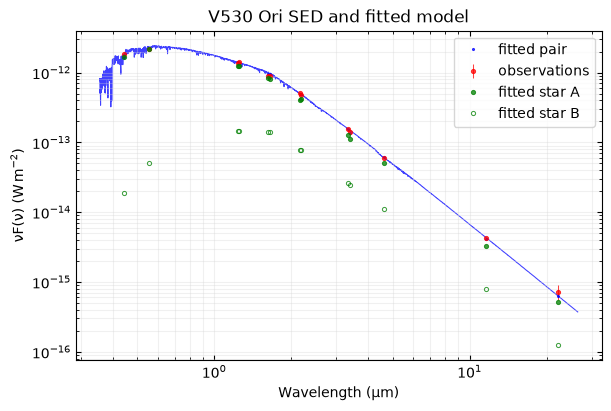

In [15]:
print(f"Fitted params from {sum(retain_mask)} retained fluxes.",
      "\nThose marked * were fitted. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_labels, theta_min, fit_mask):
    known = target_config.get(param, np.NaN) if param in target_config else None
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:.3f} {unit:unicode}",
            f"\t ({known:.3f} {unit:unicode})" if known is not None else "")

fig = plot_fitted_model(sed[retain_mask], theta_min, model_grid, sed_flux_colname="sed_fit_flux",
                        show_combined_spectrum=True, show_component_spectra=False, show_grid=True,
                        title=f"{target_data['label']} SED and fitted model")
plt.show(fig)
plt.close(fig)

### Perform MCMC sampling for parameters with uncertainties

In [16]:
thin_by = 10 # sample every nth step from the chain
nwalkers = 100
theta_mcmc, sampler = mcmc_fit(x[retain_mask],
                               y[retain_mask],
                               y_err[retain_mask],
                               theta0=theta0,
                               fit_mask=fit_mask,
                               ln_prior_func=ln_prior_func,
                               stellar_grid=model_grid,
                               nwalkers=nwalkers, nsteps=100000, thin_by=thin_by, processes=8,
                               early_stopping=True, early_stopping_from=10000,
                               progress=True, verbose=True)

mcmc_fit(theta0=[5.742e+03*, 3.785e+03*, 4.404e+00, 4.404e+00, 1.044e+00*, 6.264e-01*, 1.024e+02*, 1.395e-01*])
Running MCMC fit on 8 process(es) with 100 walkers for 100000 steps, sampling every 10 steps.
Early stopping will be considered after 10000 steps.


 10%|█         | 10000/100000 [11:55<1:47:23, 13.97it/s]

Halting MCMC sampling after 10000 steps as the walkers are beyond 100 times the autocorrelation time & the fit has converged.
Mean Acceptance fraction:    0.512
Autocorrelation steps (tau): 65.849, 66.028, 65.918, 65.695, 58.846, 64.179
Estimated burn-in steps:     140
Leaving samples of shape:    (98600, 6) *flattened
The MCMC fit yielded theta:  [(5.920+/-0.090)e+03*, (3.879+/-0.199)e+03*, (4.404+/-0)e+00, (4.404+/-0)e+00, (9.899+/-0.213)e-01*, (5.979+/-0.255)e-01*, (1.024+/-0.002)e+02*, (1.414+/-0.643)e-01*]


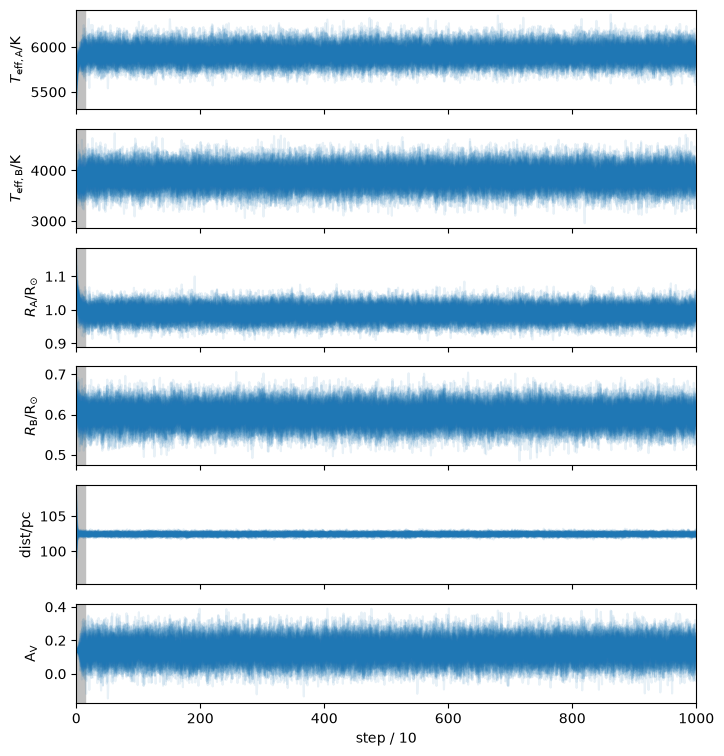

In [17]:
data = samples_from_sampler(sampler, thin_by=thin_by, flat=True)
chain = sampler.get_chain()
burn_in_samples = chain.shape[0] - (data.shape[0] / nwalkers)
fig, axes = plt.subplots(nrows=sum(fit_mask), figsize=(8, 1.5*sum(fit_mask)), sharex=True)
for ix, ax in enumerate(axes.flat):
    ax.plot(chain[:, :, ix], "tab:blue", alpha=0.1)
    ax.axvspan(0, burn_in_samples, color="silver")
    ax.set(xlim=(0, len(chain)), ylabel=theta_plot_labels[fit_mask][ix])
axes[-1].set(xlabel="step" + (f" / {thin_by}" if thin_by > 1 else ""))
plt.show(fig)
plt.close()

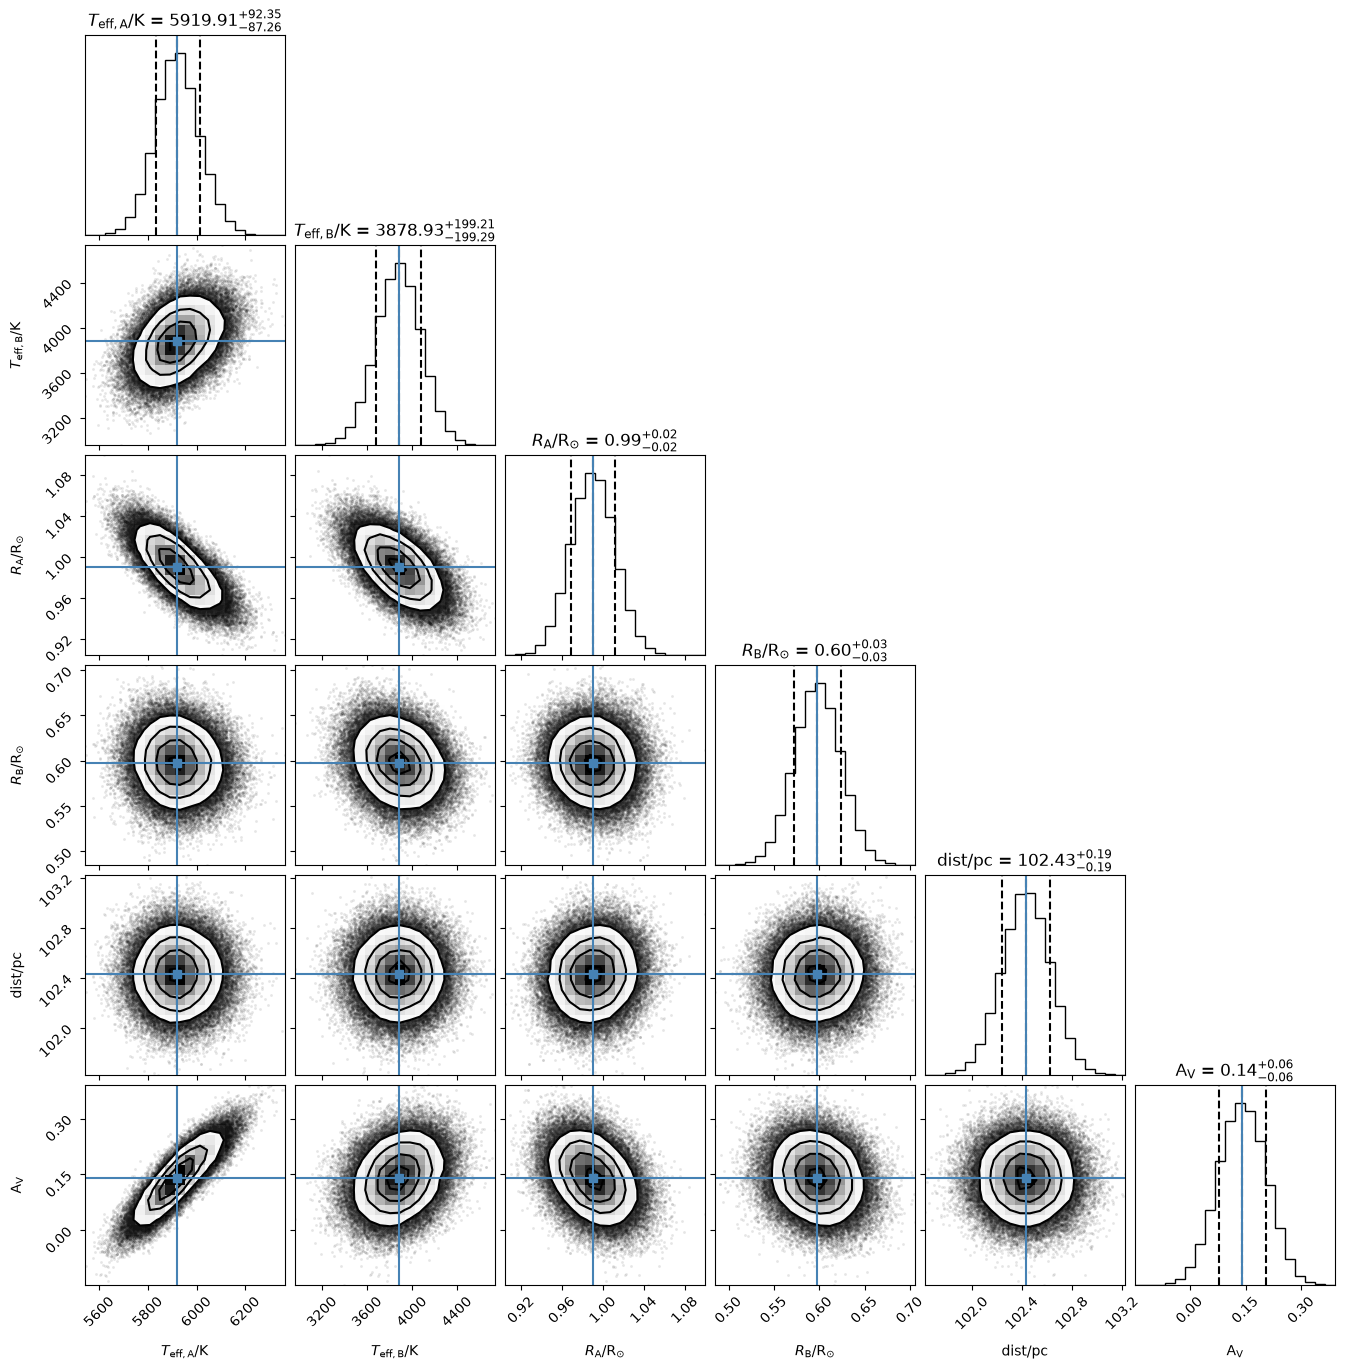

In [18]:
samples = samples_from_sampler(sampler, thin_by=thin_by, flat=True)
plt.show(corner.corner(samples, show_titles=True, plot_datapoints=True, quantiles=[0.16, 0.5, 0.84],
                       labels=theta_plot_labels[fit_mask], truths=nom_vals(theta_mcmc[fit_mask])))
plt.close()

In [19]:
print(f"Parameters for {target} with nominals & error bars from MCMC. Those marked * were fitted.")
for (param, unit), val, fitted in zip(theta_labels, theta_mcmc, fit_mask):
    known = None
    if param in target_config:
        known = ufloat(target_config.get(param, np.NaN), target_config.get(param+"_err", None) or 0)
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:.3f} {unit:unicode}",
            f"\t ({known:.3f} {unit:unicode})" if known is not None else "")
if "source" in target_config:
    print("Source of known values (in brackets):", target_config["source"])

Parameters for V530 Ori with nominals & error bars from MCMC. Those marked * were fitted.
       TeffA* = 5919.907+/-89.803 K 	 (5890.000+/-100.000 K)
       TeffB* = 3878.934+/-199.251 K 	 (3880.000+/-120.000 K)
       loggA  = 4.404+/-0 dex 	 (4.457+/-0.012 dex)
       loggB  = 4.404+/-0 dex 	 (4.676+/-0.010 dex)
          RA* = 0.990+/-0.021 R☉ 	 (0.980+/-0.013 R☉)
          RB* = 0.598+/-0.026 R☉ 	 (0.587+/-0.007 R☉)
        dist* = 102.432+/-0.192 pc 
          av* = 0.141+/-0.064  
Source of known values (in brackets): DEBCat and Torres et al. (2014) who used JKTEBOP with various non-TESS photometry sources.


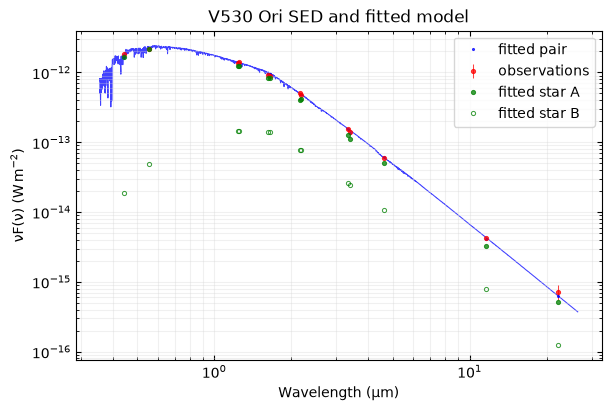

In [20]:
fig = plot_fitted_model(sed[retain_mask], theta_mcmc, model_grid, sed_flux_colname="sed_fit_flux",
                        show_combined_spectrum=True, show_component_spectra=False, show_grid=True,
                        title=f"{target_data['label']} SED and fitted model")
plt.show(fig)
plt.close(fig)